# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## 1.2 Функции

In [2]:
def visualize_predictions_comparison(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    # Конвертируем дату если нужно
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    # Сортируем по дате
    results_df = results_df.sort_values('begin')
    
    # Создаем один большой график
    plt.figure(figsize=(16, 8))
    
    # График реальных и предсказанных изменений
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    # Нулевая линия
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Настройки графика
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Красивое оформление
    plt.tight_layout()
    plt.show()

In [3]:
def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")
    
    return {
        'mae': mae,
        'rmse': rmse, 
        'r2': r2,
        'direction_accuracy': direction_accuracy
    }

In [4]:
def train_predict_rf(X_train, X_test, y_train):
    """Обучает и предсказывает Random Forest для регрессии"""
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    model = RandomForestRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Random Forest - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_dt(X_train, X_test, y_train):
    """Обучает и предсказывает Decision Tree для регрессии"""
    param_grid = {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['squared_error', 'friedman_mse']
    }
    
    model = DecisionTreeRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Decision Tree - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_linear_reg(X_train, X_test, y_train):
    """Обучает и предсказывает Linear Regression с нормализацией"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
        'fit_intercept': [True, False]
    }
    
    model = LinearRegression()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Linear Regression - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test_scaled)
    return y_pred

def train_predict_catboost(X_train, X_test, y_train):
    """Обучает и предсказывает CatBoost для регрессии"""
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [100, 200, 500]
    }
    
    model = CatBoostRegressor(verbose=False, random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"CatBoost - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

In [5]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values('begin').reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

# 2 Подготовка данных

## 2.0 Список тикеров

In [6]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.1 Чтение

In [8]:
data_SBER = pd.read_csv("stocks_SBER_processed.csv")
data_TCSG = pd.read_csv("stocks_TCSG_processed.csv")
data_GAZP = pd.read_csv("stocks_GAZP_processed.csv")
data_LKOH = pd.read_csv("stocks_LKOH_processed.csv")
data_ROSN = pd.read_csv("stocks_ROSN_processed.csv")

In [9]:
part_SBER = data_SBER[['begin', 'target_class']]
data_SBER.drop('target_class', axis=1, inplace=True)

part_TCSG = data_TCSG[['begin', 'target_class']]
data_TCSG.drop('target_class', axis=1, inplace=True)

part_GAZP = data_GAZP[['begin', 'target_class']]
data_GAZP.drop('target_class', axis=1, inplace=True)

part_LKOH = data_LKOH[['begin', 'target_class']]
data_LKOH.drop('target_class', axis=1, inplace=True)

part_ROSN = data_ROSN[['begin', 'target_class']]
data_ROSN.drop('target_class', axis=1, inplace=True)

In [10]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-07-04 10:00:00 - 2025-03-26 10:00:00 (3374 samples)
Test:  2025-03-26 12:00:00 - 2025-10-08 18:00:00 (844 samples)
Признаков: 83
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 83
Train: 2022-07-04 10:00:00 - 2025-03-26 10:00:00 (3374 samples)
Test:  2025-03-26 12:00:00 - 2025-10-08 18:00:00 (844 samples)
Признаков: 83
Train: 2022-07-04 10:00:00 - 2025-03-26 10:00:00 (3374 samples)
Test:  2025-03-26 12:00:00 - 2025-10-08 18:00:00 (844 samples)
Признаков: 83
Train: 2022-07-04 10:00:00 - 2025-03-26 10:00:00 (3374 samples)
Test:  2025-03-26 12:00:00 - 2025-10-08 18:00:00 (844 samples)
Признаков: 83


In [12]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.2620%
RMSE: 2.8271%
R²: -0.0824
Accuracy направления: 0.5190


{'mae': 2.262009991372187,
 'rmse': 2.82711925617982,
 'r2': -0.08243186520000223,
 'direction_accuracy': 0.518957345971564}

In [14]:
y_pred_TCSG = train_predict_catboost(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.9498%
RMSE: 5.0649%
R²: -0.0968
Accuracy направления: 0.4046


{'mae': 3.9497874670900197,
 'rmse': 5.064866233738689,
 'r2': -0.09683922751665097,
 'direction_accuracy': 0.404553415061296}

In [15]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.4670%
RMSE: 5.6428%
R²: 0.0393
Accuracy направления: 0.6457


{'mae': 4.467042592488985,
 'rmse': 5.642792511531315,
 'r2': 0.039286291964230835,
 'direction_accuracy': 0.6457345971563981}

In [16]:
y_pred_LKOH = train_predict_catboost(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.0684%
RMSE: 3.8092%
R²: -0.1465
Accuracy направления: 0.4834


{'mae': 3.0684246716223442,
 'rmse': 3.8091840949790123,
 'r2': -0.14653729948569283,
 'direction_accuracy': 0.4834123222748815}

In [17]:
y_pred_ROSN = train_predict_catboost(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.8861%
RMSE: 4.8980%
R²: -0.2463
Accuracy направления: 0.4775


{'mae': 3.886074441804659,
 'rmse': 4.898018534703145,
 'r2': -0.2463221262759958,
 'direction_accuracy': 0.4774881516587678}

In [13]:
gb_model_SBER = CatBoostRegressor(depth=8, learning_rate=0.01, l2_leaf_reg=5, iterations=100, verbose=False, random_state=13)
gb_model_SBER.fit(X_train_SBER, y_train_SBER)
y_pred_SBER = gb_model_SBER.predict(X_test_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.2620%
RMSE: 2.8271%
R²: -0.0824
Accuracy направления: 0.5190


{'mae': 2.262009991372187,
 'rmse': 2.82711925617982,
 'r2': -0.08243186520000223,
 'direction_accuracy': 0.518957345971564}

In [18]:
gb_model_TCSG = CatBoostRegressor(depth=4, learning_rate=0.01, l2_leaf_reg=1, iterations=100, verbose=False, random_state=13)
gb_model_TCSG.fit(X_train_TCSG, y_train_TCSG)
y_pred_TCSG = gb_model_TCSG.predict(X_test_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)


📊 МОДЕЛЬ: 
MAE: 3.9498%
RMSE: 5.0649%
R²: -0.0968
Accuracy направления: 0.4046


{'mae': 3.9497874670900197,
 'rmse': 5.064866233738689,
 'r2': -0.09683922751665097,
 'direction_accuracy': 0.404553415061296}

In [19]:
gb_model_GAZP = CatBoostRegressor(depth=8, learning_rate=0.01, l2_leaf_reg=1, iterations=100, verbose=False, random_state=13)
gb_model_GAZP.fit(X_train_GAZP, y_train_GAZP)
y_pred_GAZP = gb_model_GAZP.predict(X_test_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.4670%
RMSE: 5.6428%
R²: 0.0393
Accuracy направления: 0.6457


{'mae': 4.467042592488985,
 'rmse': 5.642792511531315,
 'r2': 0.039286291964230835,
 'direction_accuracy': 0.6457345971563981}

In [20]:
gb_model_LKOH = CatBoostRegressor(depth=8, learning_rate=0.01, l2_leaf_reg=5, iterations=100, verbose=False, random_state=13)
gb_model_LKOH.fit(X_train_LKOH, y_train_LKOH)
y_pred_LKOH = gb_model_LKOH.predict(X_test_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)


📊 МОДЕЛЬ: 
MAE: 3.0684%
RMSE: 3.8092%
R²: -0.1465
Accuracy направления: 0.4834


{'mae': 3.0684246716223442,
 'rmse': 3.8091840949790123,
 'r2': -0.14653729948569283,
 'direction_accuracy': 0.4834123222748815}

In [21]:
gb_model_ROSN = CatBoostRegressor(depth=8, learning_rate=0.01, l2_leaf_reg=5, iterations=100, verbose=False, random_state=13)
gb_model_ROSN.fit(X_train_ROSN, y_train_ROSN)
y_pred_ROSN = gb_model_ROSN.predict(X_test_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)


📊 МОДЕЛЬ: 
MAE: 3.8861%
RMSE: 4.8980%
R²: -0.2463
Accuracy направления: 0.4775


{'mae': 3.886074441804659,
 'rmse': 4.898018534703145,
 'r2': -0.2463221262759958,
 'direction_accuracy': 0.4774881516587678}

In [22]:
import pickle

with open('SBER_model.pkl', 'wb') as f:
    pickle.dump(gb_model_SBER, f)
    
with open('TCSG_model.pkl', 'wb') as f:
    pickle.dump(gb_model_TCSG, f)
    
with open('GAZP_model.pkl', 'wb') as f:
    pickle.dump(gb_model_LKOH, f)
    
with open('LKOH_model.pkl', 'wb') as f:
    pickle.dump(gb_model_SBER, f)
    
with open('ROSN_model.pkl', 'wb') as f:
    pickle.dump(gb_model_ROSN, f)

In [29]:
X_test_SBER.to_csv("test_SBER.csv", index = False)

In [22]:
data_SBER = pd.read_csv("data/stocks_features_SBER.csv")
data_TCSG = pd.read_csv("data/stocks_features_TCSG.csv")
data_GAZP = pd.read_csv("data/stocks_features_GAZP.csv")
data_LKOH = pd.read_csv("data/stocks_features_LKOH.csv")
data_ROSN = pd.read_csv("data/stocks_features_ROSN.csv")
data_ROSN.head(2)

,begin,close,MA_14,MA_50,MA_90,MA_14_50_DIFF,MA_50_90_DIFF,MA_14_50_RATIO,MA_50_90_RATIO,RSI_14,...,MOM_90,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLATILITY_90,VOLUME_RATIO_20,MACD_SIGNAL,MACD_HISTOGRAM,target_price_change,target_class
0,2022-06-01 10:00:00,378.35,387.425000,383.684,385.708333,3.741000,-2.024333,1.009750,0.994752,43.536971,...,-5.495192,6.960488,0.153935,0.177697,0.171953,0.770980,1.125999,-1.986196,-1.361174,L
1,2022-06-01 12:00:00,379.45,385.992857,383.204,385.477778,2.788857,-2.273778,1.007278,0.994101,45.055941,...,-5.184908,6.545453,0.153509,0.177854,0.172052,0.413804,0.690690,-1.741234,-1.805244,L


## 2.2 Удаление лишних признаков

In [23]:
# Для SBER
part_SBER = data_SBER[['begin', 'close', 'target_class']]
data_SBER.drop(['close', 'target_class'], axis=1, inplace=True)

# Для TCSG
part_TCSG = data_TCSG[['begin', 'close', 'target_class']]
data_TCSG.drop(['close', 'target_class'], axis=1, inplace=True)

# Для GAZP
part_GAZP = data_GAZP[['begin', 'close', 'target_class']]
data_GAZP.drop(['close', 'target_class'], axis=1, inplace=True)

# Для LKOH
part_LKOH = data_LKOH[['begin', 'close', 'target_class']]
data_LKOH.drop(['close', 'target_class'], axis=1, inplace=True)

# Для ROSN
part_ROSN = data_ROSN[['begin', 'close', 'target_class']]
data_ROSN.drop(['close', 'target_class'], axis=1, inplace=True)

## 2.3 Разделение на train/test

In [24]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-06-01 10:00:00 - 2025-03-11 14:00:00 (3426 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 24
Train: 2022-06-01 10:00:00 - 2024-06-03 10:00:00 (2366 samples)
Test:  2024-06-03 12:00:00 - 2024-11-20 18:00:00 (592 samples)
Признаков: 24
Train: 2022-06-01 10:00:00 - 2025-03-11 14:00:00 (3426 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 24
Train: 2022-06-01 10:00:00 - 2025-03-11 14:00:00 (3426 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 24
Train: 2022-06-01 10:00:00 - 2025-03-11 14:00:00 (3426 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 24


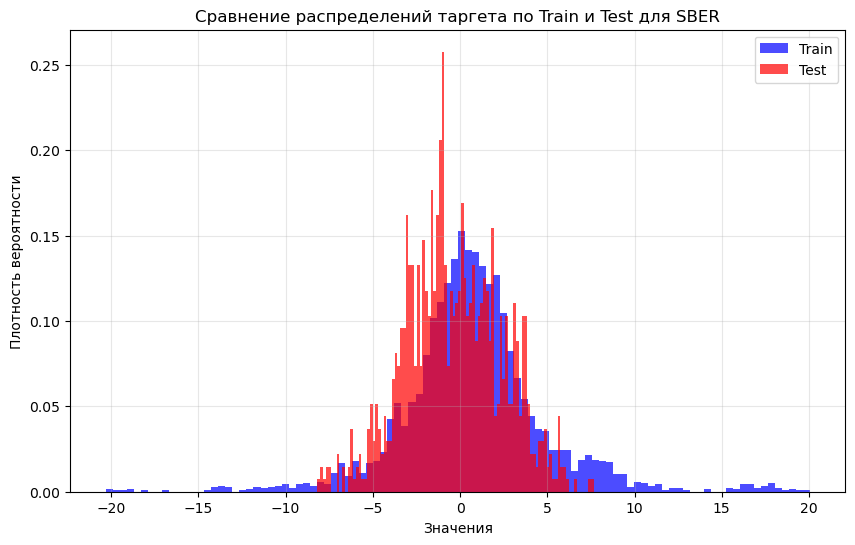

In [25]:
plt.figure(figsize = (10, 6))
plt.hist(y_train_SBER, bins = 100, alpha = 0.7, label = 'Train', color = 'blue', density = True)
plt.hist(y_test_SBER, bins = 100, alpha = 0.7, label = 'Test', color = 'red', density = True)
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределений таргета по Train и Test для SBER')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

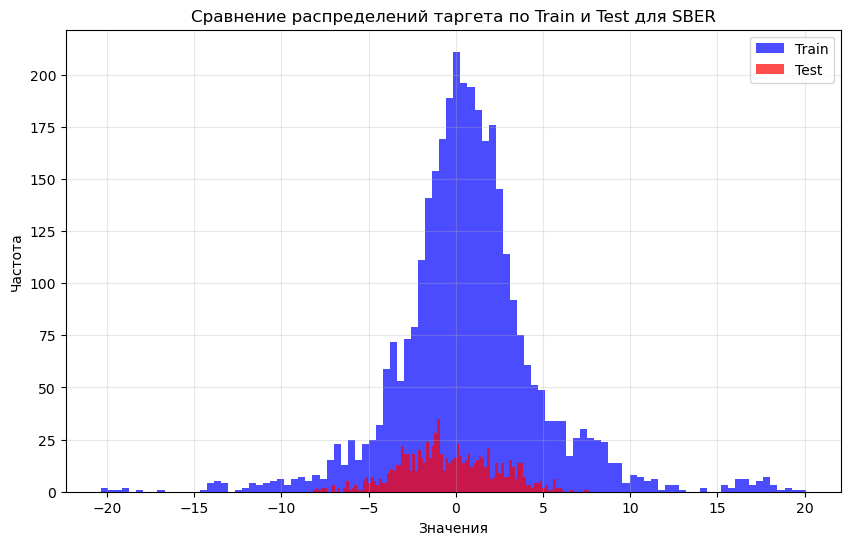

In [26]:
plt.figure(figsize = (10, 6))
plt.hist(y_train_SBER, bins = 100, alpha = 0.7, label = 'Train', color = 'blue')
plt.hist(y_test_SBER, bins = 100, alpha = 0.7, label = 'Test', color = 'red')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.title('Сравнение распределений таргета по Train и Test для SBER')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

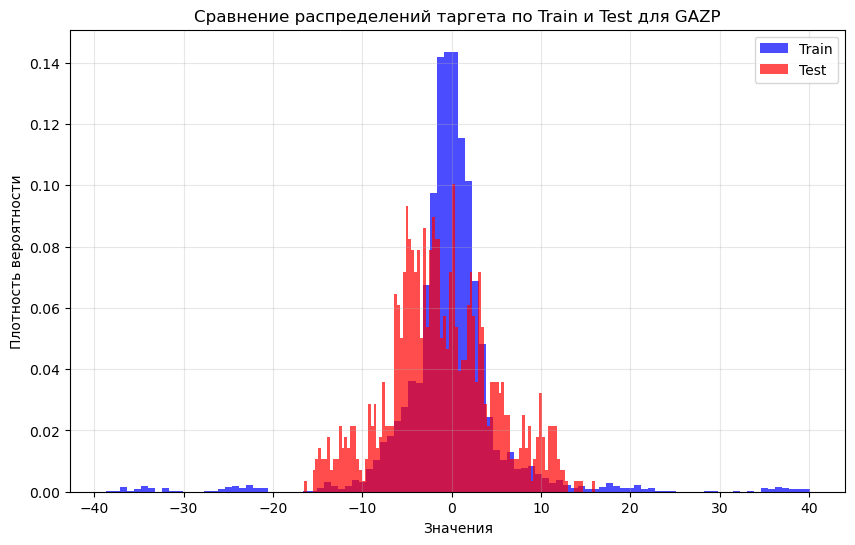

In [27]:
plt.figure(figsize = (10, 6))
plt.hist(y_train_GAZP, bins = 100, alpha = 0.7, label = 'Train', color = 'blue', density = True)
plt.hist(y_test_GAZP, bins = 100, alpha = 0.7, label = 'Test', color = 'red', density = True)
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределений таргета по Train и Test для GAZP')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

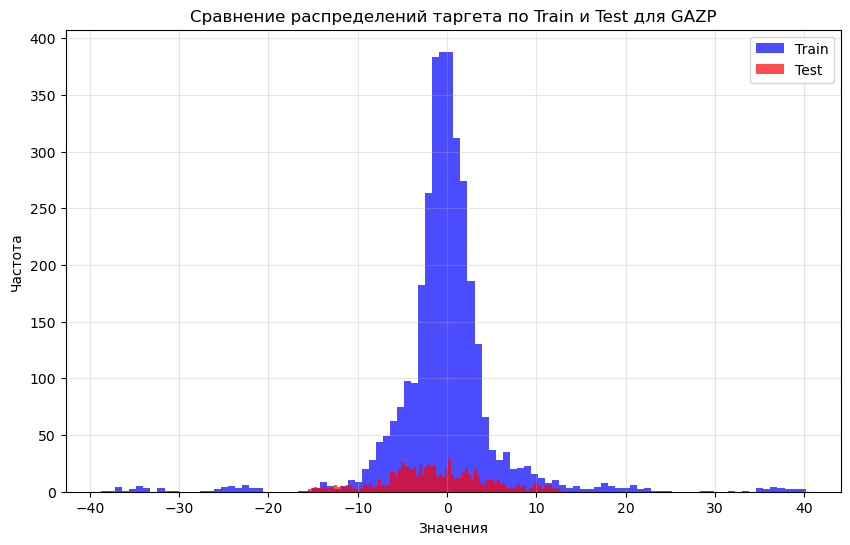

In [28]:
plt.figure(figsize = (10, 6))
plt.hist(y_train_GAZP, bins = 100, alpha = 0.7, label = 'Train', color = 'blue')
plt.hist(y_test_GAZP, bins = 100, alpha = 0.7, label = 'Test', color = 'red')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.title('Сравнение распределений таргета по Train и Test для GAZP')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

# 3 Обучение моделей с подбором гиперпараметров

## 3.1 Дерево решений

### 3.1.1 Сбер

In [15]:
# Базовая
y_pred_SBER = train_predict_dt(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Decision Tree - лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

📊 МОДЕЛЬ: 
MAE: 2.6561%
RMSE: 3.3333%
R²: -0.4490
Accuracy направления: 0.4912


{'mae': 2.6560966284764973,
 'rmse': np.float64(3.3332702172668607),
 'r2': -0.4490429614082063,
 'direction_accuracy': np.float64(0.4912485414235706)}

In [31]:
# Первое добавление всего
y_pred_SBER = train_predict_dt(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

📊 МОДЕЛЬ: 
MAE: 2.4783%
RMSE: 3.0501%
R²: -0.2133
Accuracy направления: 0.4889


{'mae': 2.4782764466447875,
 'rmse': np.float64(3.050124034292026),
 'r2': -0.2133196152420136,
 'direction_accuracy': np.float64(0.48891481913652274)}

### 3.1.2 Тиньк

In [24]:
y_pred_TCSG = train_predict_dt(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Decision Tree - лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 3.7348%
RMSE: 4.8433%
R²: -0.0214
Accuracy направления: 0.5963


{'mae': 3.7348302874619352,
 'rmse': 4.84331769944399,
 'r2': -0.021414045582956343,
 'direction_accuracy': 0.5962837837837838}

### 3.1.3 Газпром

In [16]:
# Базовая
y_pred_GAZP = train_predict_dt(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 5.0659%
RMSE: 6.4070%
R²: -0.1614
Accuracy направления: 0.6079


{'mae': 5.065885959422821,
 'rmse': np.float64(6.406966052524934),
 'r2': -0.16136584521553177,
 'direction_accuracy': np.float64(0.6079346557759626)}

In [32]:
# Первое добавление всего
y_pred_GAZP = train_predict_dt(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 4.7976%
RMSE: 6.0312%
R²: -0.0291
Accuracy направления: 0.6079


{'mae': 4.797611877934725,
 'rmse': np.float64(6.03119564009872),
 'r2': -0.029131891412090605,
 'direction_accuracy': np.float64(0.6079346557759626)}

### 3.1.4 Лукойл

In [28]:
y_pred_LKOH = train_predict_dt(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 3.3266%
RMSE: 4.1812%
R²: -0.3891
Accuracy направления: 0.4994


{'mae': 3.326592725062546,
 'rmse': 4.181205234102082,
 'r2': -0.38911544996233705,
 'direction_accuracy': 0.49941656942823803}

### 3.1.5 Роснефть

In [30]:
y_pred_ROSN = train_predict_dt(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

📊 МОДЕЛЬ: 
MAE: 5.9056%
RMSE: 7.0320%
R²: -1.4977
Accuracy направления: 0.5438


{'mae': 5.905607727216033,
 'rmse': 7.0319775085680245,
 'r2': -1.497690708807744,
 'direction_accuracy': 0.543757292882147}

## Вывод

Кажется, MAE достаточно большая

## 3.2 Регрессия

### 3.2.1 Сбер

In [35]:
y_pred_SBER = train_predict_linear_reg(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 2.3672%
RMSE: 2.9339%
R²: -0.1226
Accuracy направления: 0.5158


{'mae': 2.367174503894134,
 'rmse': 2.9339273082333417,
 'r2': -0.12263587577737578,
 'direction_accuracy': 0.5157526254375729}

### 3.2.2 Тиньк

In [37]:
y_pred_TCSG = train_predict_linear_reg(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Linear Regression - лучшие параметры: {'fit_intercept': True}

📊 МОДЕЛЬ: 
MAE: 3.9208%
RMSE: 5.0267%
R²: -0.1002
Accuracy направления: 0.4426


{'mae': 3.920754624027114,
 'rmse': 5.026672916850483,
 'r2': -0.10021399203209569,
 'direction_accuracy': 0.44256756756756754}

### 3.2.3 Газпром

In [39]:
y_pred_GAZP = train_predict_linear_reg(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 5.2179%
RMSE: 6.2516%
R²: -0.1057
Accuracy направления: 0.4667


{'mae': 5.217944653403911,
 'rmse': 6.251555174369449,
 'r2': -0.10570771755839714,
 'direction_accuracy': 0.46674445740956827}

### 3.2.4 Лукойл

In [41]:
y_pred_LKOH = train_predict_linear_reg(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 2.7737%
RMSE: 3.4846%
R²: 0.0352
Accuracy направления: 0.6044


{'mae': 2.773682983164515,
 'rmse': 3.4846243466107687,
 'r2': 0.0351777635527194,
 'direction_accuracy': 0.6044340723453909}

### 3.2.5 Роснефть

In [43]:
y_pred_ROSN = train_predict_linear_reg(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 3.7700%
RMSE: 4.6411%
R²: -0.0880
Accuracy направления: 0.4936


{'mae': 3.7700369755228986,
 'rmse': 4.64109155299955,
 'r2': -0.08798769514347438,
 'direction_accuracy': 0.4935822637106184}

## Вывод

Результаты лучше чем у дерева

## 3.3 Вот он, лес

### 3.3.1 Сбер

In [14]:
# Базовая
y_pred_SBER = train_predict_rf(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

📊 МОДЕЛЬ: 
MAE: 2.4431%
RMSE: 3.0354%
R²: -0.2016
Accuracy направления: 0.5321


{'mae': 2.443082502971086,
 'rmse': 3.035375178954789,
 'r2': -0.20161398653932316,
 'direction_accuracy': 0.5320886814469078}

In [33]:
# Добавление всего
y_pred_SBER = train_predict_rf(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 2.4676%
RMSE: 2.9687%
R²: -0.1494
Accuracy направления: 0.4889


{'mae': 2.467644759203855,
 'rmse': np.float64(2.9687107134707795),
 'r2': -0.1494126628614154,
 'direction_accuracy': np.float64(0.48891481913652274)}

In [29]:
# Без подбора гиперпараметров
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER, y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER)

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.5408%
RMSE: 3.0228%
R²: -0.1917
Accuracy направления: 0.5333


{'mae': 2.540819867111692,
 'rmse': 3.0227732636286158,
 'r2': -0.19165725756386998,
 'direction_accuracy': 0.5332555425904317}

In [30]:
# Удаление MA_90
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER.drop('MA_90', axis = 1), y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER.drop('MA_90', axis = 1))

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.5036%
RMSE: 3.0150%
R²: -0.1856
Accuracy направления: 0.5438


{'mae': 2.503618151793923,
 'rmse': 3.0150481116613617,
 'r2': -0.18557412178941446,
 'direction_accuracy': 0.543757292882147}

In [31]:
# Удаление MA_90, MA_50
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER.drop(['MA_90', 'MA_50'], axis = 1), y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER.drop(['MA_90', 'MA_50'], axis = 1))

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.4837%
RMSE: 2.9852%
R²: -0.1622
Accuracy направления: 0.5228


{'mae': 2.4836936944581183,
 'rmse': 2.985239024953556,
 'r2': -0.1622470126285478,
 'direction_accuracy': 0.5227537922987164}

In [74]:
# Удаление MA_90, MA_50 с подбором гиперпараметров
y_pred_SBER = train_predict_rf(X_train_SBER.drop(['MA_90', 'MA_50'], axis = 1), X_test_SBER.drop(['MA_90', 'MA_50'], axis = 1), y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

📊 МОДЕЛЬ: 
MAE: 2.4289%
RMSE: 2.9192%
R²: -0.1114
Accuracy направления: 0.4971


{'mae': 2.4288552580126064,
 'rmse': np.float64(2.9191837274450885),
 'r2': -0.11138127862024216,
 'direction_accuracy': np.float64(0.4970828471411902)}

In [15]:
# Длина предсказания 2 без подбора гиперпараметров с удалением MA_90
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER.drop('MA_90', axis = 1), y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER.drop('MA_90', axis = 1))

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 1.1473%
RMSE: 1.5081%
R²: -0.1945
Accuracy направления: 0.5246


{'mae': 1.147300323870923,
 'rmse': np.float64(1.5081362472593087),
 'r2': -0.19447829517600468,
 'direction_accuracy': np.float64(0.5246179966044142)}

In [14]:
# Длина предсказания 2 без подбора гиперпараметров с добавлением всего
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER, y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER)

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 1.2225%
RMSE: 1.5490%
R²: -0.2601
Accuracy направления: 0.5314


{'mae': 1.2224595820393236,
 'rmse': np.float64(1.5490190806397774),
 'r2': -0.2601163342657593,
 'direction_accuracy': np.float64(0.5314091680814941)}

### 3.3.2 Тиньк

In [55]:
y_pred_TCSG = train_predict_rf(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 4.4003%
RMSE: 5.7748%
R²: -0.4521
Accuracy направления: 0.4730


{'mae': 4.400304952095433,
 'rmse': 5.774799635521811,
 'r2': -0.45207734919508913,
 'direction_accuracy': 0.47297297297297297}

### 3.3.3 Газпром

In [18]:
# Базовая
y_pred_GAZP = train_predict_rf(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 5.1083%
RMSE: 6.6386%
R²: -0.2469
Accuracy направления: 0.4947


{'mae': 5.108288459172111,
 'rmse': 6.6386493119118635,
 'r2': -0.24687712926693028,
 'direction_accuracy': 0.49474912485414235}

In [35]:
# Первое добавление всего
y_pred_GAZP = train_predict_rf(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

📊 МОДЕЛЬ: 
MAE: 4.9091%
RMSE: 6.4436%
R²: -0.1747
Accuracy направления: 0.5613


{'mae': 4.9090848022265625,
 'rmse': np.float64(6.443578961986068),
 'r2': -0.17467713054836986,
 'direction_accuracy': np.float64(0.5612602100350058)}

In [32]:
# Без подбора гиперпараметров
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP, y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP)

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 5.0468%
RMSE: 6.5804%
R²: -0.2251
Accuracy направления: 0.5461


{'mae': 5.046825810338854,
 'rmse': 6.580366098622303,
 'r2': -0.22507962355183975,
 'direction_accuracy': 0.5460910151691949}

In [52]:
# Удалене MA_90
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP.drop('MA_90', axis = 1), y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP.drop('MA_90', axis = 1))

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.7260%
RMSE: 6.2117%
R²: -0.0917
Accuracy направления: 0.5869


{'mae': 4.726024550690878,
 'rmse': np.float64(6.2116899406571635),
 'r2': -0.09165081433775657,
 'direction_accuracy': np.float64(0.5869311551925321)}

In [66]:
# Удалене MA_90, MA_50
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP.drop(['MA_90', 'MA_50'], axis = 1), y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP.drop(['MA_90', 'MA_50'], axis = 1))

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.6735%
RMSE: 6.1430%
R²: -0.0676
Accuracy направления: 0.5846


{'mae': 4.673546518741119,
 'rmse': np.float64(6.142950231547639),
 'r2': -0.06762367897999022,
 'direction_accuracy': np.float64(0.5845974329054843)}

In [77]:
# Удаление MA_90, MA_50 с подбором гиперпараметров
y_pred_GAZP = train_predict_rf(X_train_GAZP.drop(['MA_90', 'MA_50'], axis = 1), X_test_GAZP.drop(['MA_90', 'MA_50'], axis = 1), y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

📊 МОДЕЛЬ: 
MAE: 4.5907%
RMSE: 6.0448%
R²: -0.0338
Accuracy направления: 0.6079


{'mae': 4.5906614351234465,
 'rmse': np.float64(6.044759495325923),
 'r2': -0.033766028110080004,
 'direction_accuracy': np.float64(0.6079346557759626)}

In [18]:
# Длина предсказания 2 без подбора гиперпараметров с добавлением всего
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP, y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP)

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 2.6092%
RMSE: 3.2845%
R²: -0.9685
Accuracy направления: 0.5144


{'mae': 2.609196536371627,
 'rmse': np.float64(3.284514374286201),
 'r2': -0.9685252481467144,
 'direction_accuracy': np.float64(0.5144312393887945)}

### 3.3.4 Лукойл

In [63]:
y_pred_LKOH = train_predict_rf(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 3.5188%
RMSE: 4.3747%
R²: -0.5207
Accuracy направления: 0.4644


{'mae': 3.5187512008122184,
 'rmse': 4.374708264355947,
 'r2': -0.5206650483231843,
 'direction_accuracy': 0.4644107351225204}

### 3.3.5 Роснефть

In [65]:
y_pred_ROSN = train_predict_rf(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

📊 МОДЕЛЬ: 
MAE: 4.5863%
RMSE: 5.6731%
R²: -0.6256
Accuracy направления: 0.5018


{'mae': 4.586301644543559,
 'rmse': 5.6730514700998285,
 'r2': -0.6256129861168125,
 'direction_accuracy': 0.5017502917152858}

## Вывод

Качесто где-то лучше чем у регрессии а где-то хуже

## 3.4 Бустинг

### 3.4.1 Сбер

In [70]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.2797%
RMSE: 2.7896%
R²: -0.0149
Accuracy направления: 0.4901


{'mae': 2.279691040318903,
 'rmse': 2.789626567625175,
 'r2': -0.01492128071658927,
 'direction_accuracy': 0.49008168028004667}

### 3.4.2 Тиньк

In [72]:
y_pred_TCSG = train_predict_catboost(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.8693%
RMSE: 4.9980%
R²: -0.0877
Accuracy направления: 0.4088


{'mae': 3.869267352335807,
 'rmse': 4.997960367816026,
 'r2': -0.08768095985907265,
 'direction_accuracy': 0.40878378378378377}

### 3.4.3 Газпром

In [74]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

CatBoost - лучшие параметры: {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.8854%
RMSE: 6.0842%
R²: -0.0473
Accuracy направления: 0.5834


{'mae': 4.885382907727858,
 'rmse': 6.084165695466093,
 'r2': -0.04728834409148375,
 'direction_accuracy': 0.5834305717619603}

### 3.4.4 Лукойл

In [76]:
y_pred_LKOH = train_predict_catboost(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.9925%
RMSE: 3.7581%
R²: -0.1222
Accuracy направления: 0.4959


{'mae': 2.9924812222992228,
 'rmse': 3.758122660739855,
 'r2': -0.12221810912592823,
 'direction_accuracy': 0.4959159859976663}

### 3.4.5 Роснефть

In [78]:
y_pred_ROSN = train_predict_catboost(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.9168%
RMSE: 4.8092%
R²: -0.1682
Accuracy направления: 0.5123


{'mae': 3.916839582161037,
 'rmse': 4.809177200602996,
 'r2': -0.16822170611495046,
 'direction_accuracy': 0.5122520420070011}

## Вывод

На всех акциях кроме Газпрома качество предсказаний улучшилось

Таким образом лучше всего работает опять бустинг

# 4 Визуализация резульататов

## 4.1 Сбер

In [25]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(part_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
df_SBER_pred.head()

,target_price_change,begin,predict
3374,-4.187316,2025-03-26 12:00:00,-0.337745
3375,-4.374019,2025-03-26 14:00:00,0.950088
3376,-3.767264,2025-03-26 16:00:00,1.625914
3377,-3.684244,2025-03-26 18:00:00,4.459741
3378,-2.849148,2025-03-27 10:00:00,4.409642


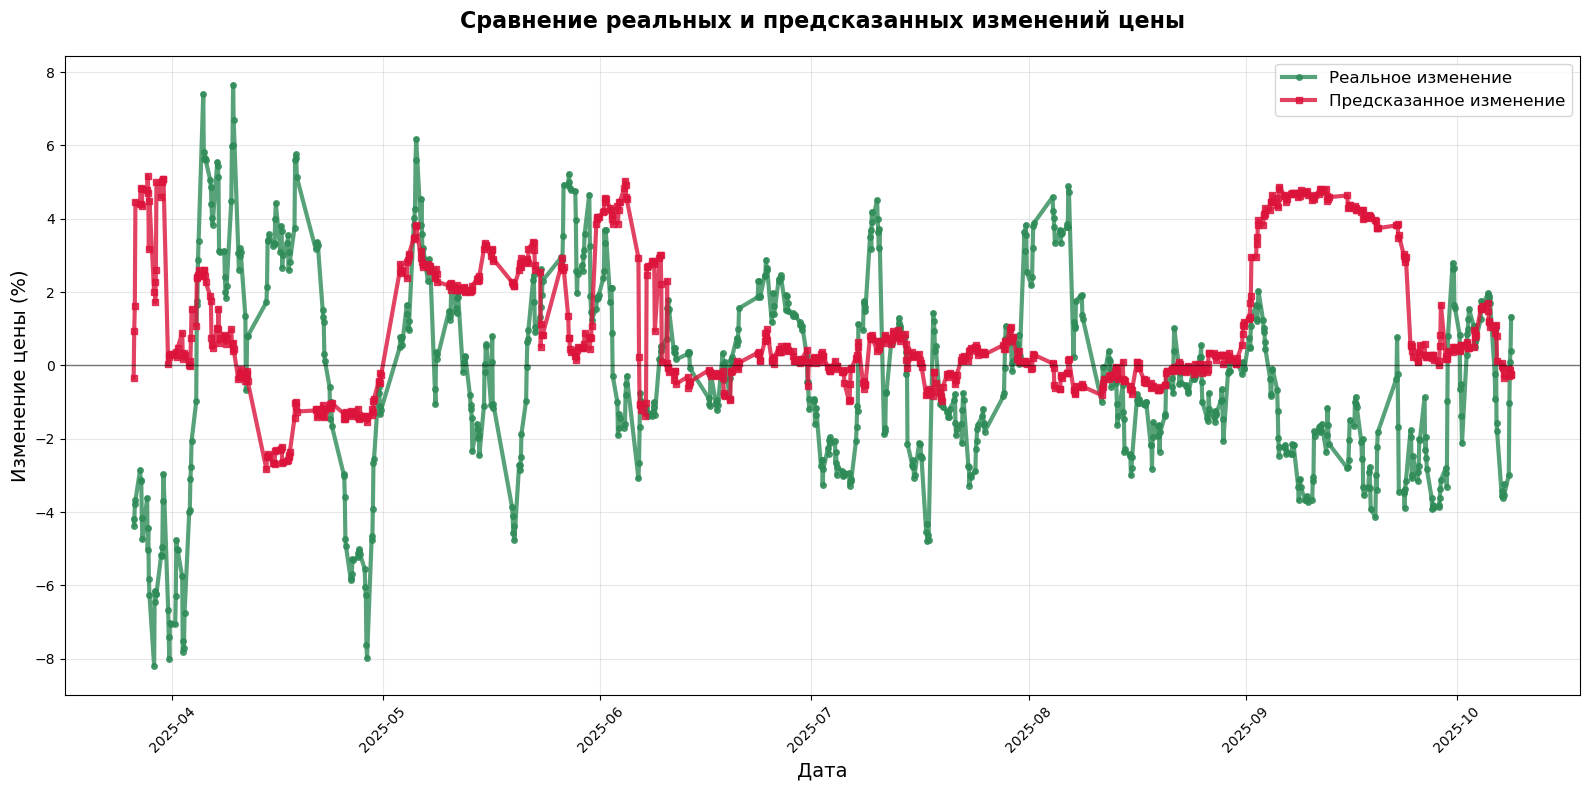

In [26]:
visualize_predictions_comparison(df_SBER_pred)

## 4.2 Газпром

In [53]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
df_GAZP_pred.head()

,target_price_change,begin,close,predict
2363,-2.164857,2025-05-13 18:00:00,146.43,-2.513191
2364,-2.283861,2025-05-14 10:00:00,144.93,-2.171833
2365,-2.684702,2025-05-14 12:00:00,145.64,-2.713499
2366,-2.602740,2025-05-14 14:00:00,146.00,-2.933511
2367,-2.956952,2025-05-14 16:00:00,145.42,-2.759070


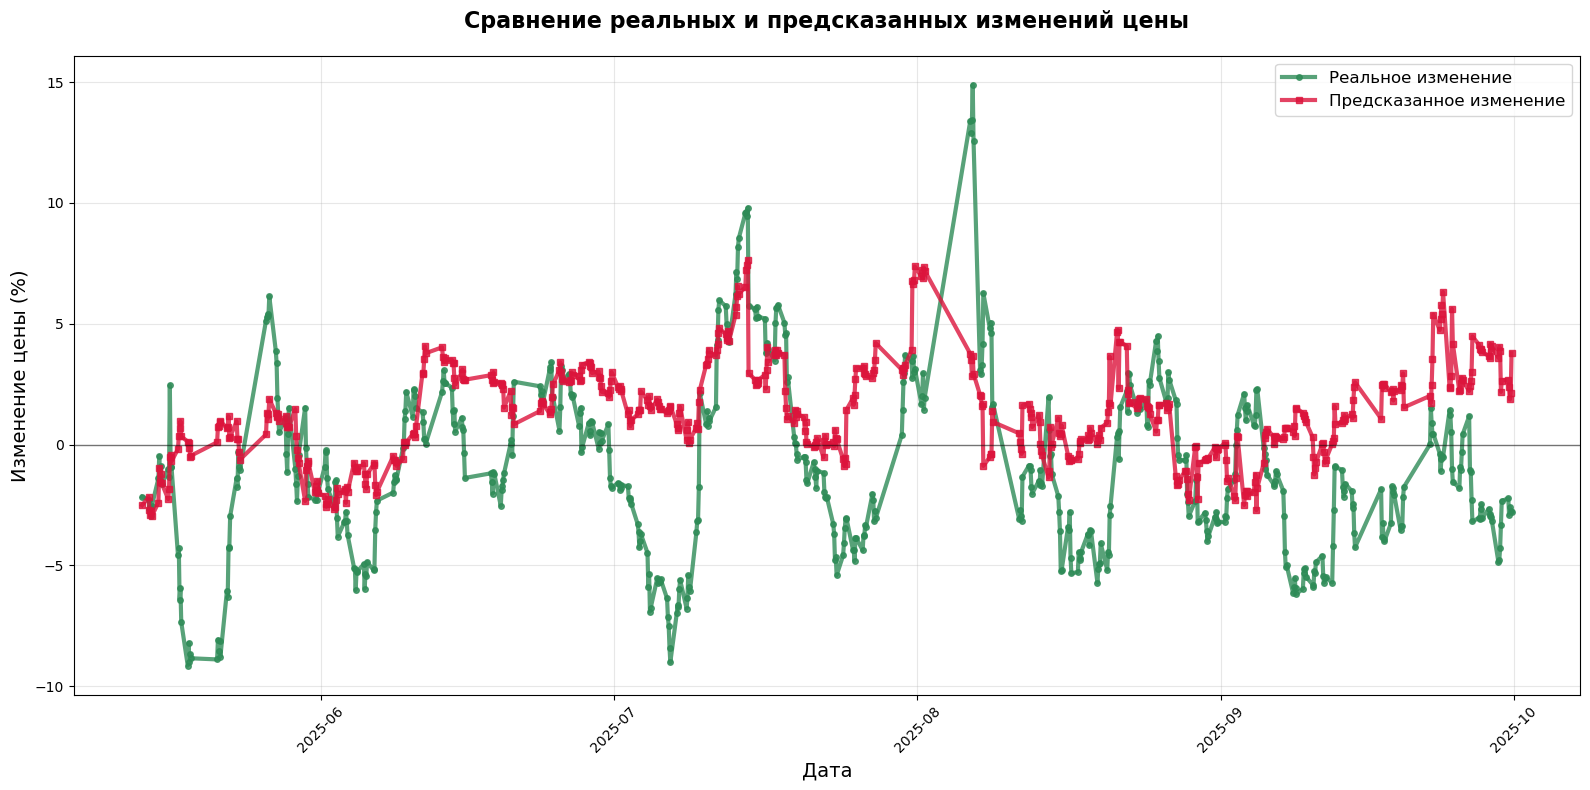

In [54]:
visualize_predictions_comparison(df_GAZP_pred)

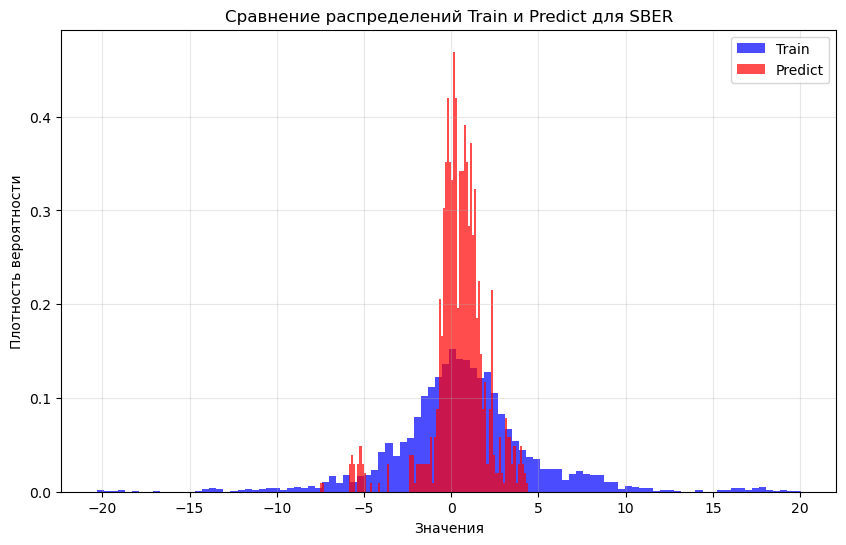

In [82]:
plt.figure(figsize = (10, 6))
plt.hist(y_train_SBER, bins = 100, alpha = 0.7, label='Train', color = 'blue', density = True)
plt.hist(df_SBER_pred['predict'], bins = 100, alpha = 0.7, label = 'Predict', color = 'red', density = True)
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределений Train и Predict для SBER')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

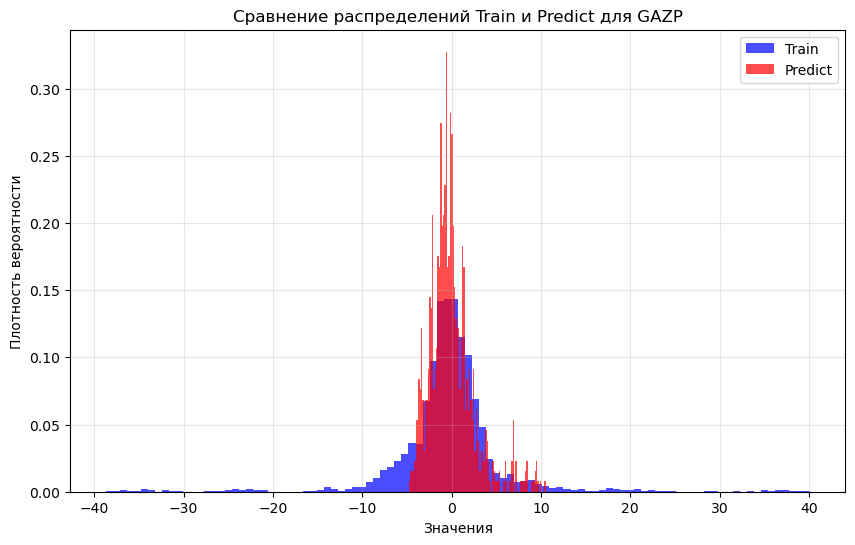

In [83]:
plt.figure(figsize = (10, 6))
plt.hist(y_train_GAZP, bins = 100, alpha = 0.7, label = 'Train', color = 'blue', density = True)
plt.hist(df_GAZP_pred['predict'], bins = 100, alpha = 0.7, label = 'Predict', color = 'red', density = True)
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределений Train и Predict для GAZP')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

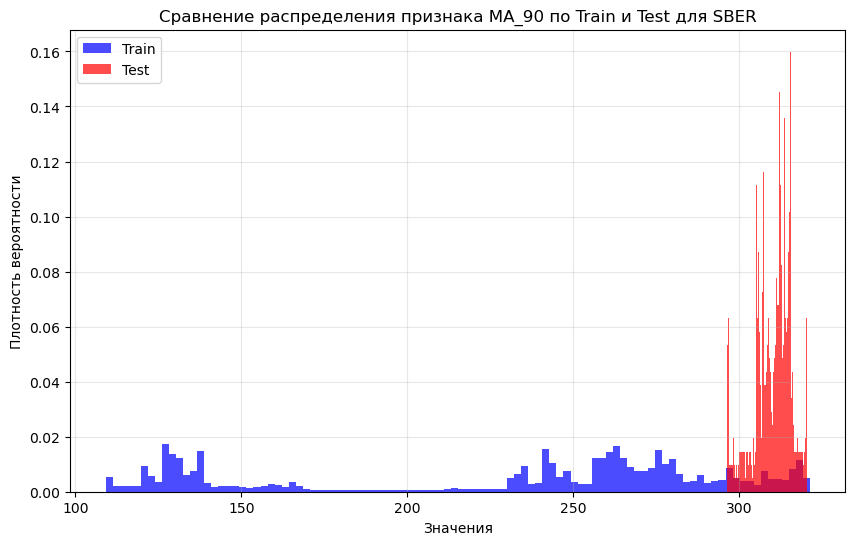

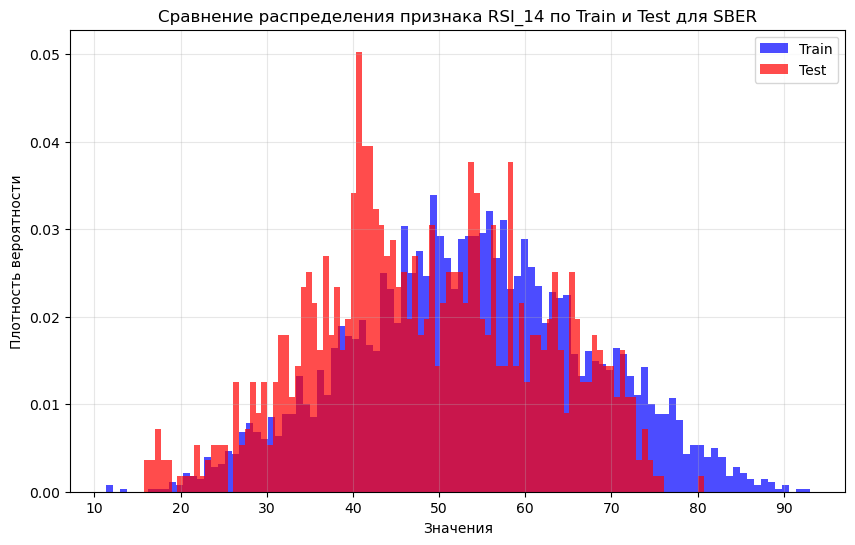

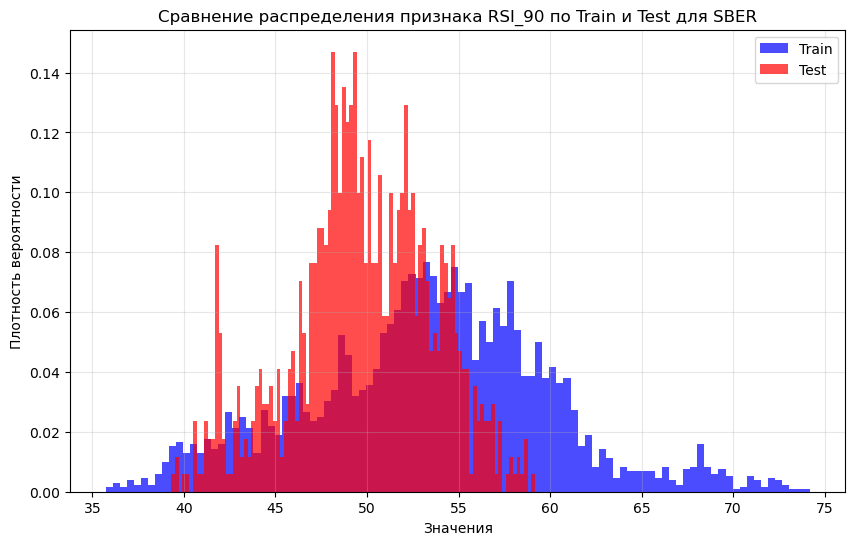

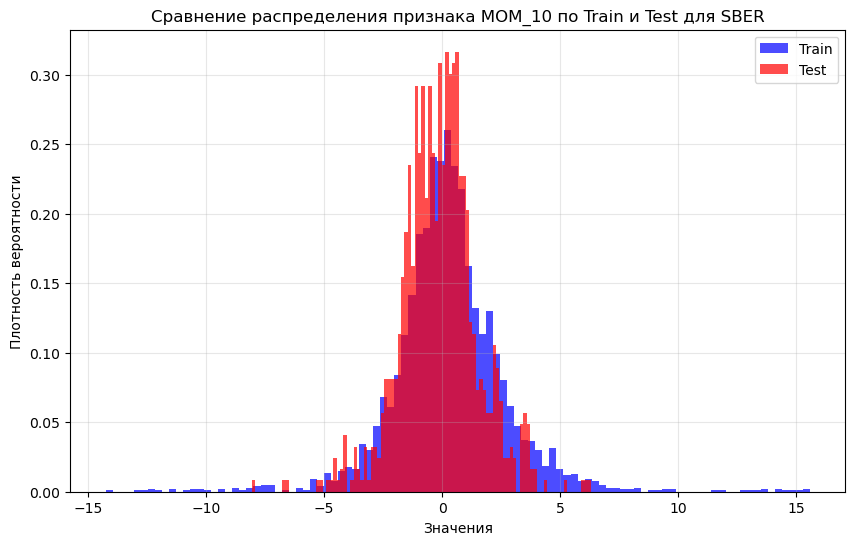

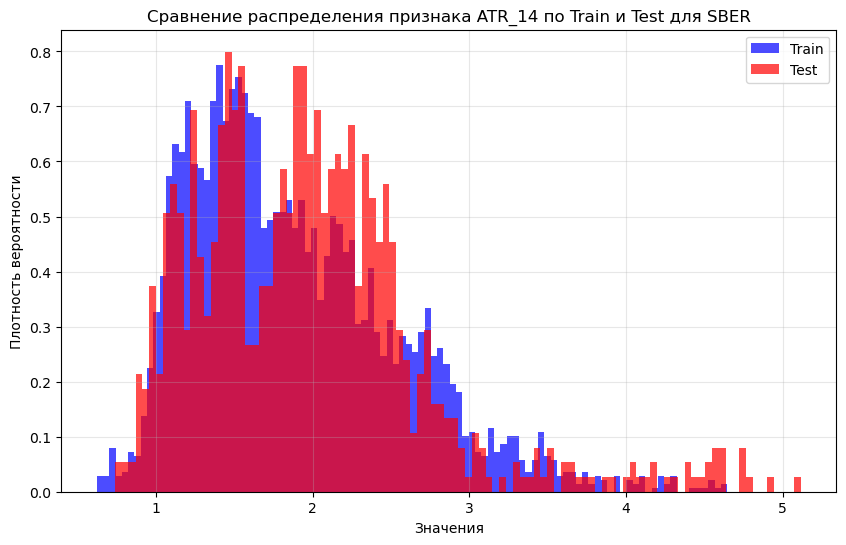

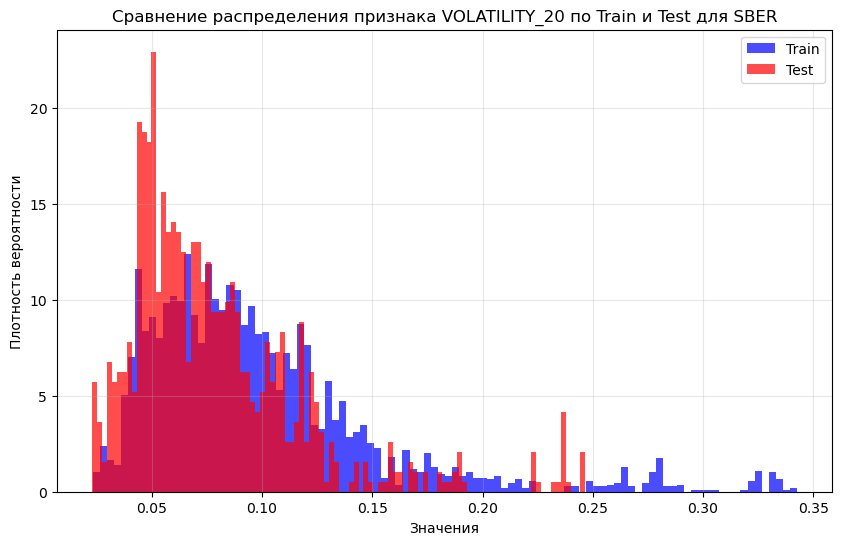

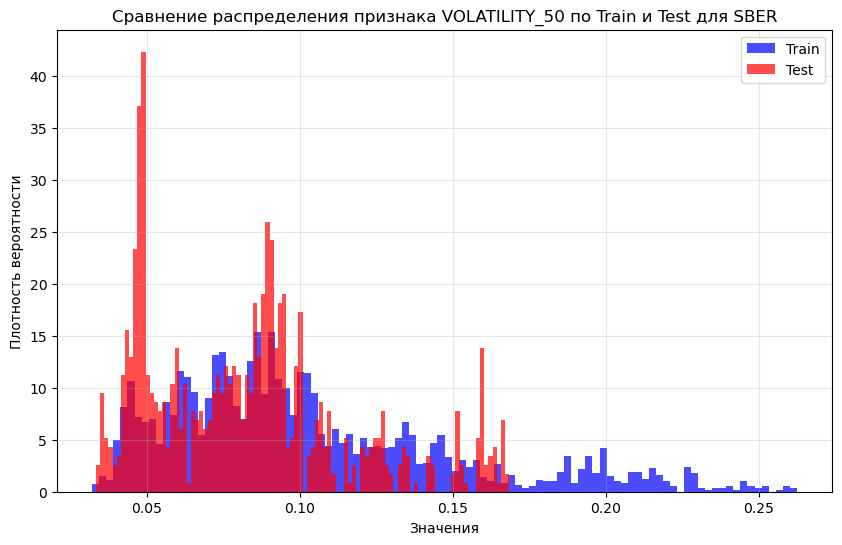

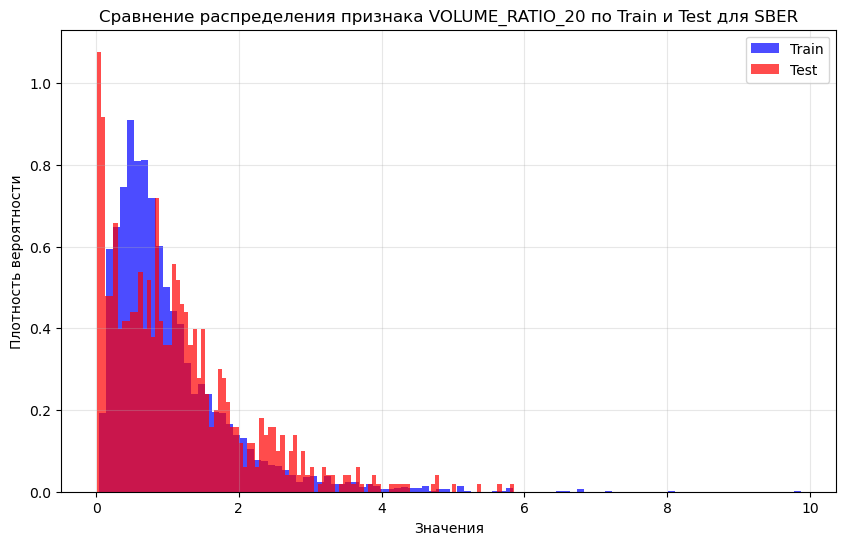

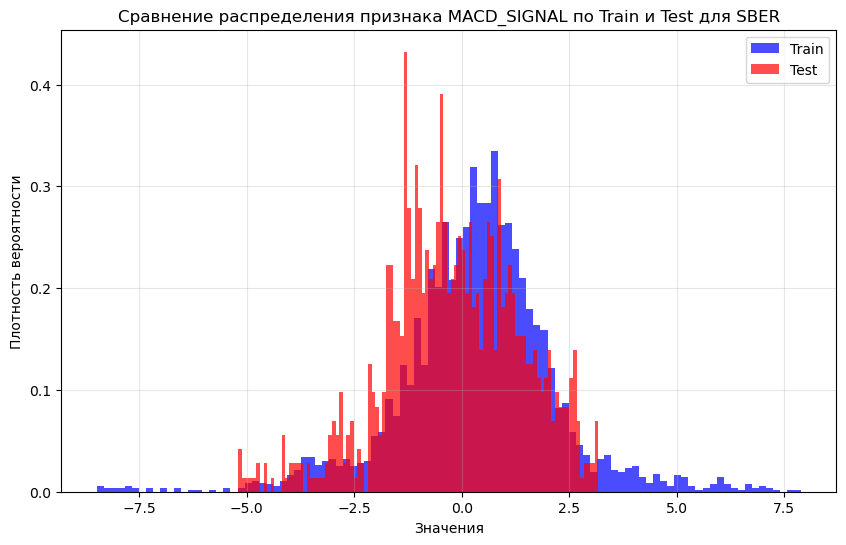

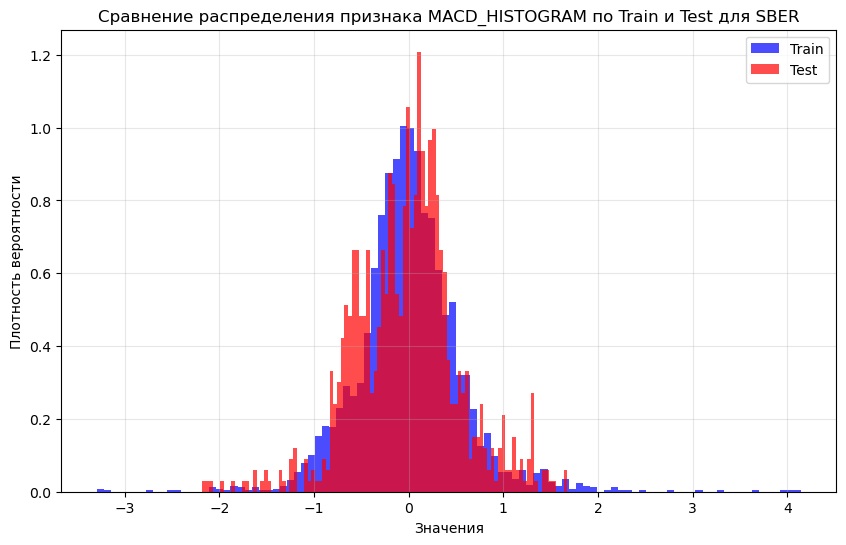

In [68]:
for col in X_train_SBER.columns:
    plt.figure(figsize = (10, 6))
    plt.hist(X_train_SBER[col], bins = 100, alpha = 0.7, label = 'Train', color = 'blue', density = True)
    plt.hist(X_test_SBER[col], bins = 100, alpha = 0.7, label = 'Test', color = 'red', density = True)
    plt.xlabel('Значения')
    plt.ylabel('Плотность вероятности')
    plt.title(f'Сравнение распределения признака {col} по Train и Test для SBER')
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.show()

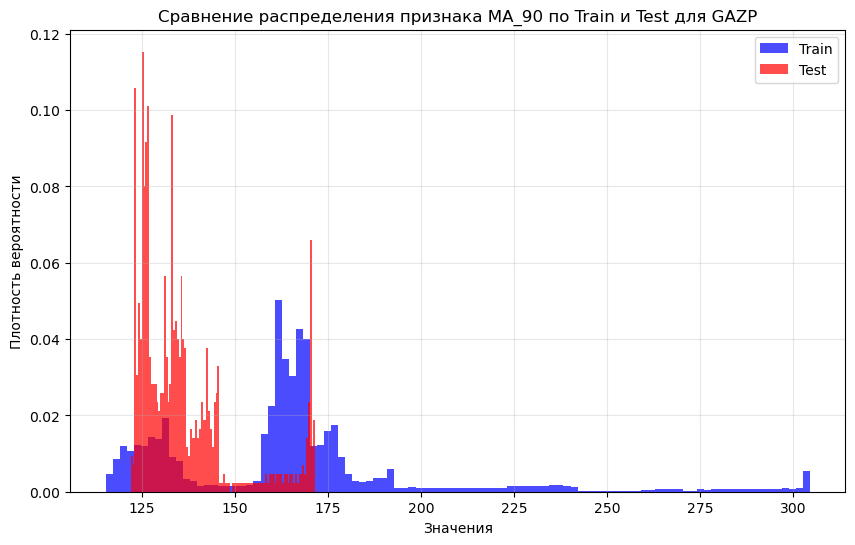

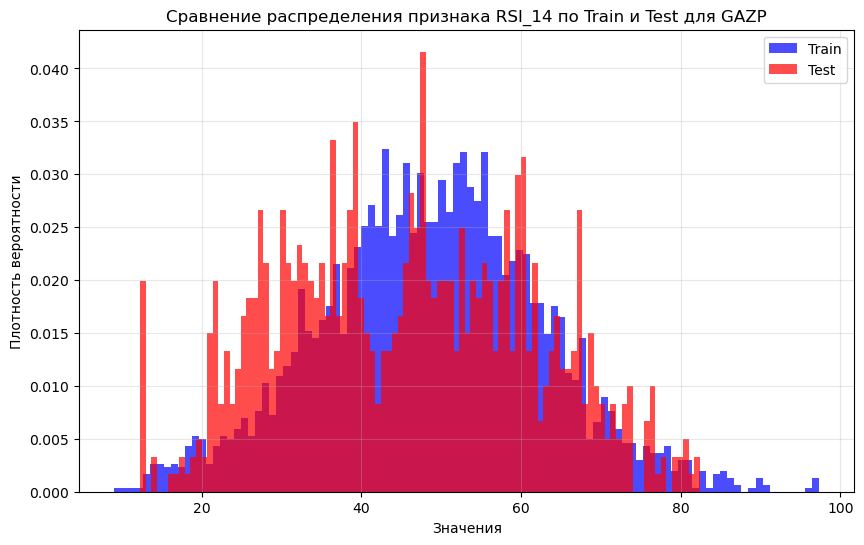

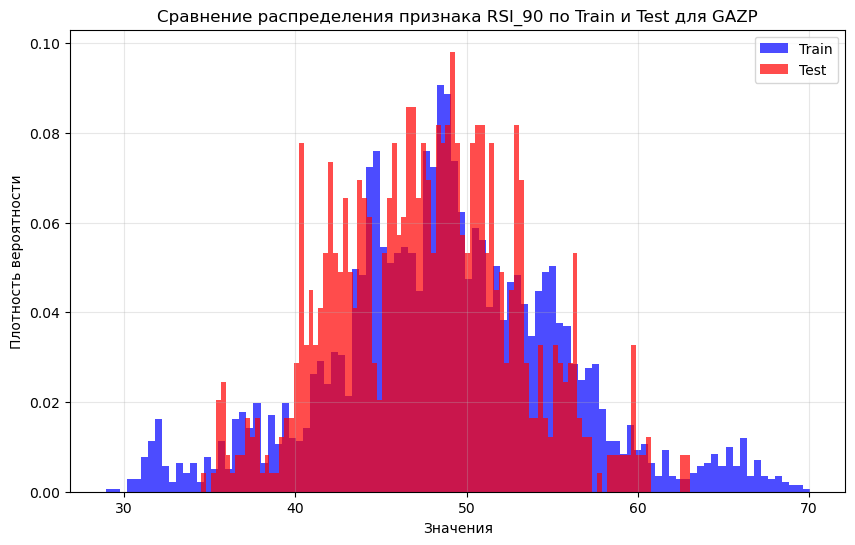

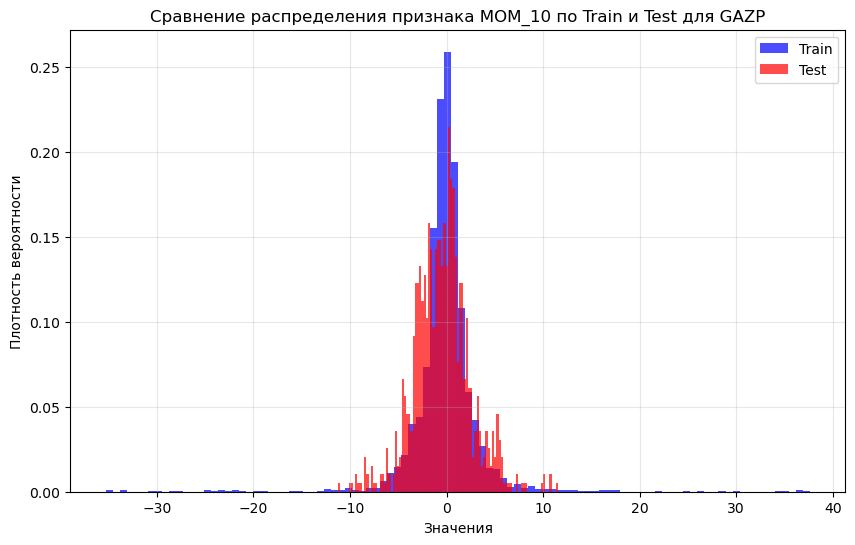

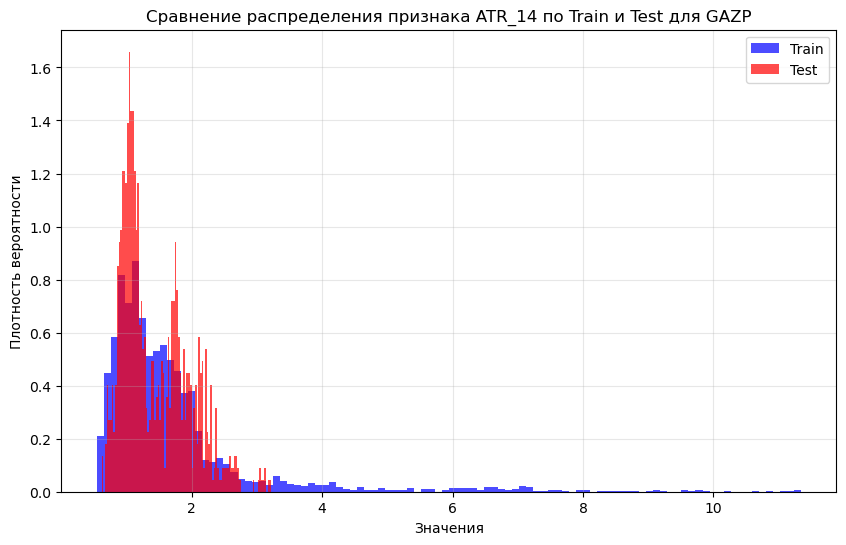

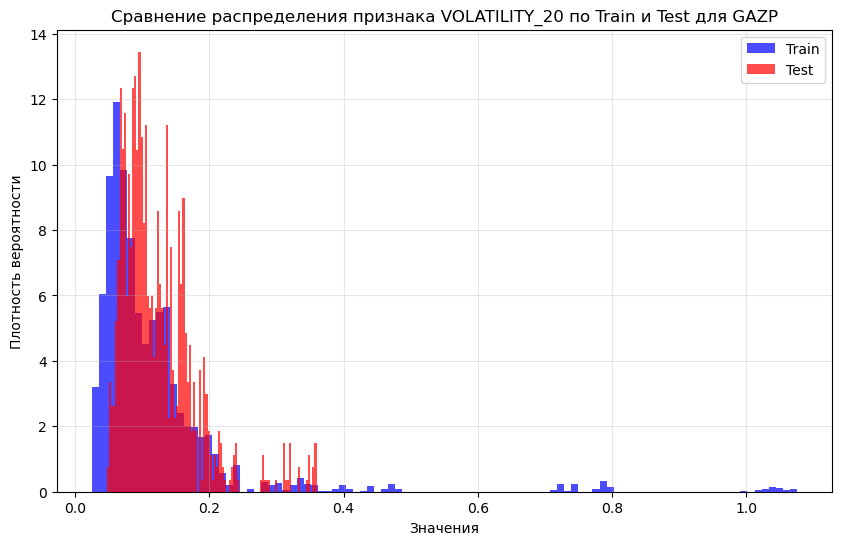

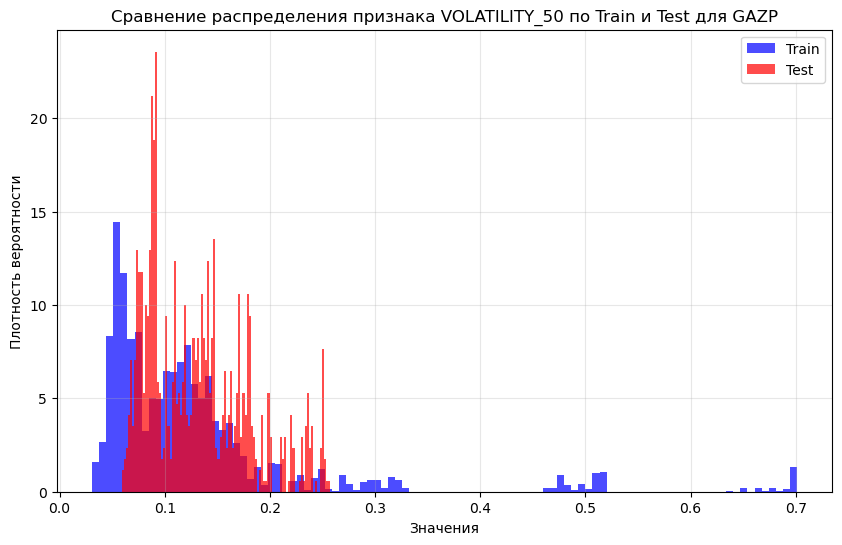

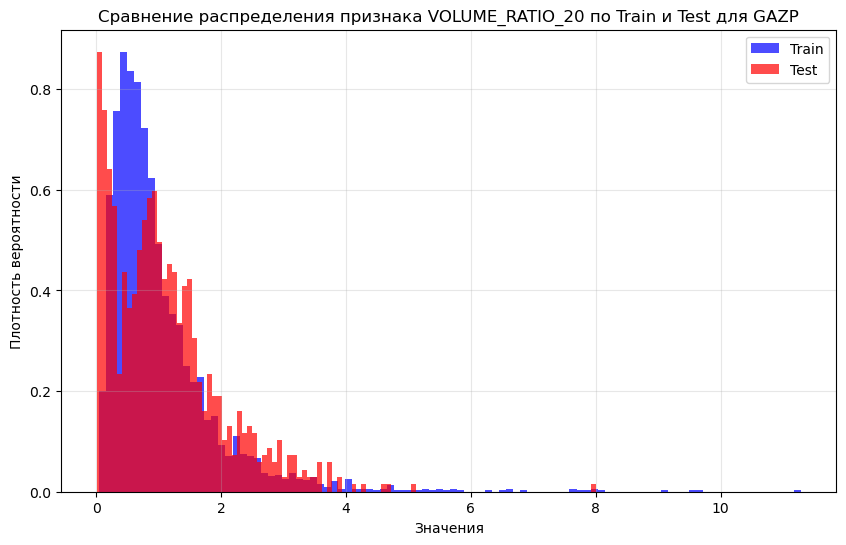

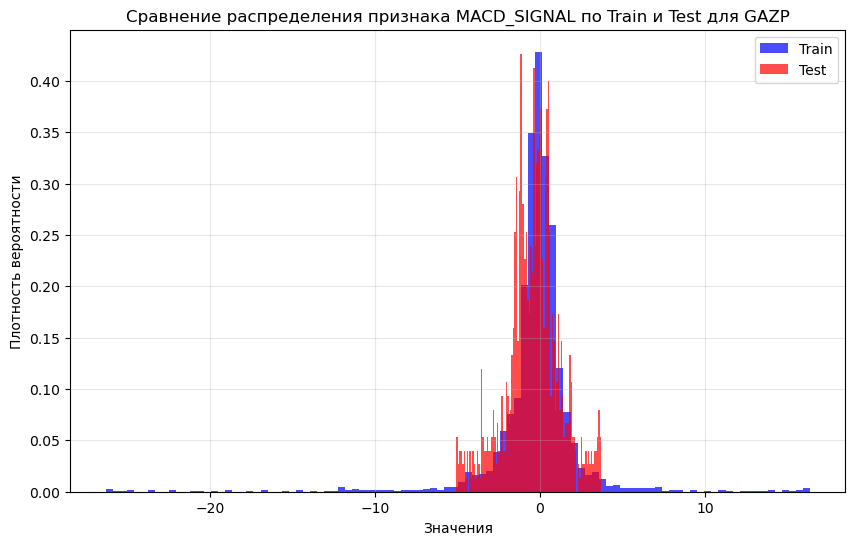

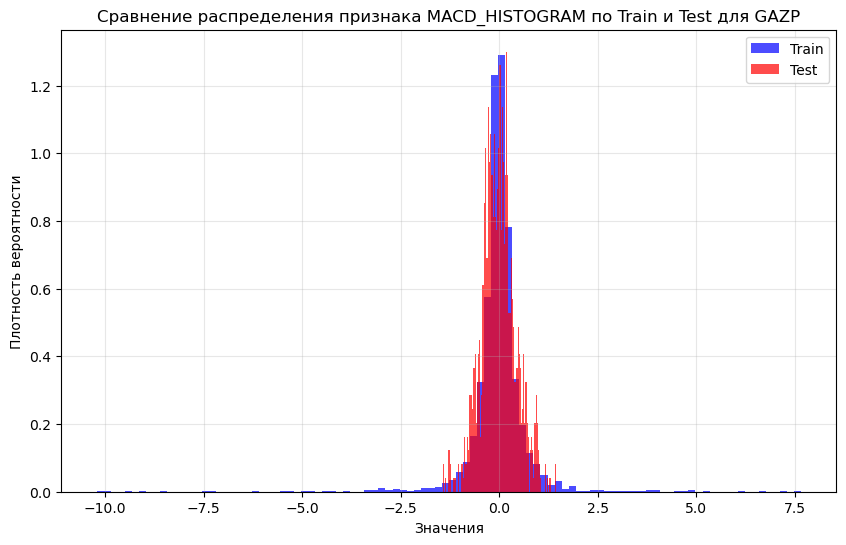

In [69]:
for col in X_train_GAZP.columns:
    plt.figure(figsize = (10, 6))
    plt.hist(X_train_GAZP[col], bins = 100, alpha = 0.7, label = 'Train', color = 'blue', density = True)
    plt.hist(X_test_GAZP[col], bins = 100, alpha = 0.7, label = 'Test', color = 'red', density = True)
    plt.xlabel('Значения')
    plt.ylabel('Плотность вероятности')
    plt.title(f'Сравнение распределения признака {col} по Train и Test для GAZP')
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.show()

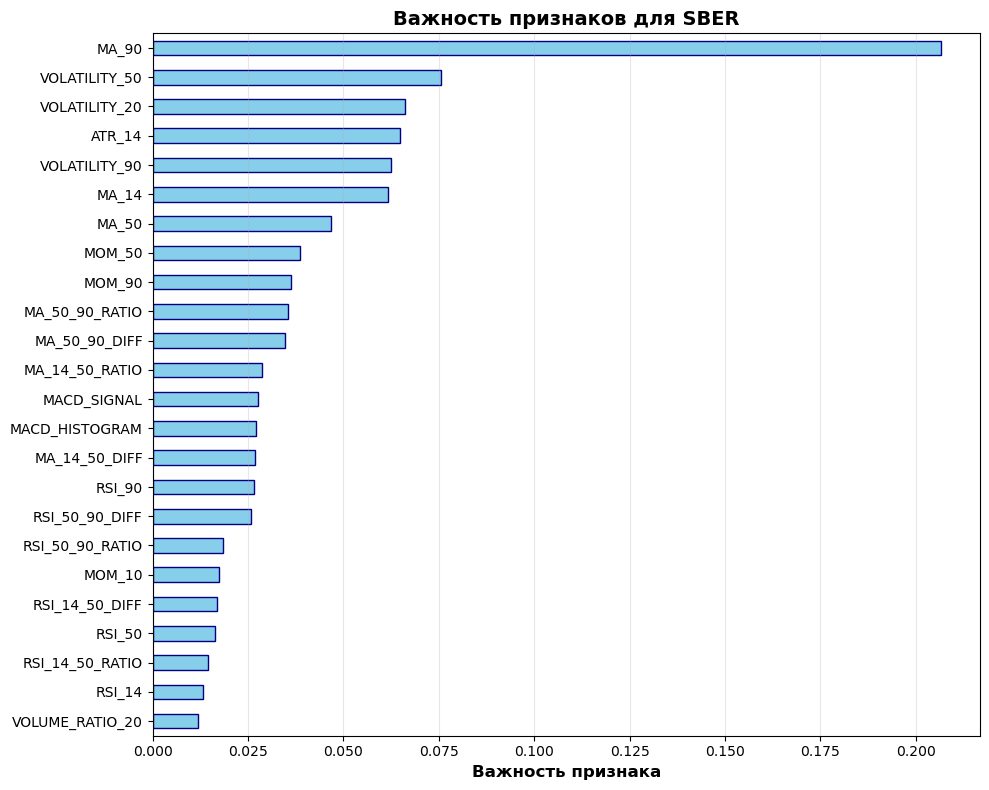

In [104]:
# rf_model_SBER = RandomForestRegressor(random_state = 13, max_depth = 10, min_samples_leaf = 1, min_samples_split = 5, n_estimators = 50)
# rf_model_SBER.fit(X_train_SBER.drop(['MA_90', 'MA_50'], axis = 1), y_train_SBER)

# importances = pd.Series(rf_model_SBER.feature_importances_, index = X_train_SBER.columns).sort_values(ascending = True)
importances = pd.Series(rf_model_SBER.feature_importances_, index = X_train_SBER.drop(['MA_90', 'MA_50'], axis = 1).columns).sort_values(ascending = True)

plt.figure(figsize = (10, 8))
importances.plot.barh(color = 'skyblue', edgecolor = 'navy')
plt.xlabel('Важность признака', fontsize = 12, fontweight = 'bold')
plt.title('Важность признаков для SBER', fontsize = 14, fontweight = 'bold')
plt.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

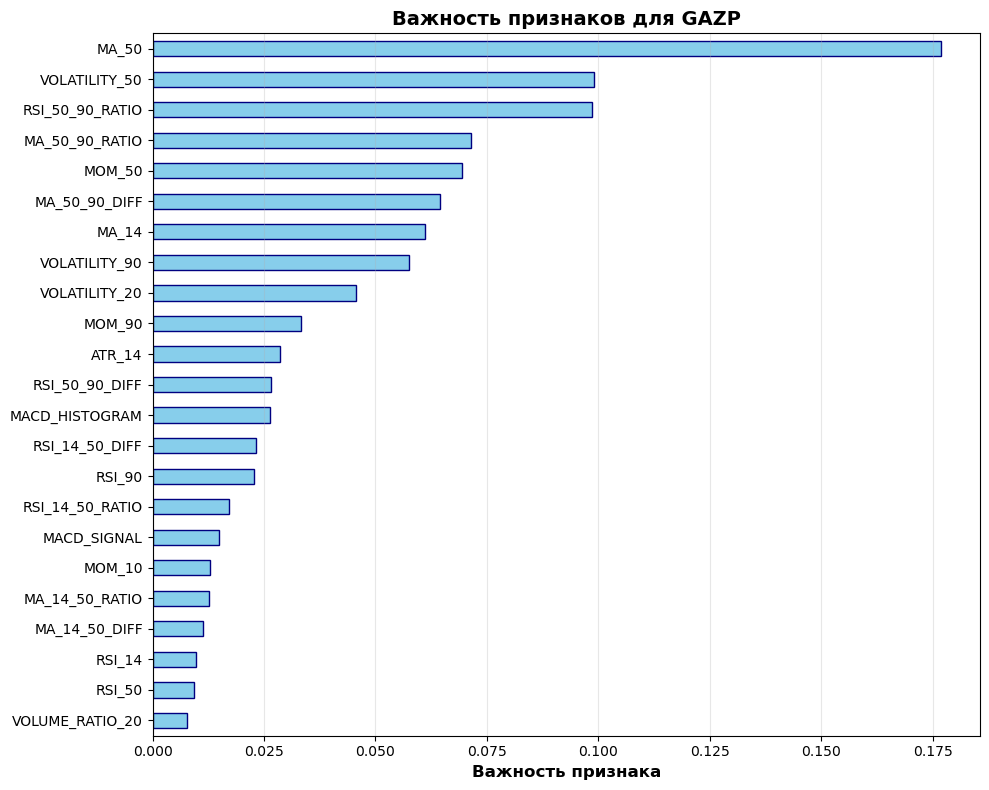

In [26]:
# rf_model_GAZP = RandomForestRegressor(random_state = 13, max_depth = 10, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 50)
# rf_model_GAZP.fit(X_train_GAZP.drop(['MA_90', 'MA_50'], axis = 1), y_train_GAZP)

# importances = pd.Series(rf_model_GAZP.feature_importances_, index = X_train_GAZP.columns).sort_values(ascending = True)
importances = pd.Series(rf_model_GAZP.feature_importances_, index = X_train_GAZP.drop('MA_90', axis = 1).columns).sort_values(ascending = True)
# importances = pd.Series(rf_model_GAZP.feature_importances_, index = X_train_GAZP.drop(['MA_90', 'MA_50'], axis = 1).columns).sort_values(ascending = True)

plt.figure(figsize = (10, 8))
importances.plot.barh(color = 'skyblue', edgecolor = 'navy')
plt.xlabel('Важность признака', fontsize = 12, fontweight = 'bold')
plt.title('Важность признаков для GAZP', fontsize = 14, fontweight = 'bold')
plt.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

In [25]:
# Длина предсказания 2 без подбора гиперпараметров с удалением MA_90
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP.drop('MA_90', axis = 1), y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP.drop('MA_90', axis = 1))

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 2.5918%
RMSE: 3.2140%
R²: -0.8849
Accuracy направления: 0.5127


{'mae': 2.5918157131436304,
 'rmse': np.float64(3.214028409554605),
 'r2': -0.8849423768113109,
 'direction_accuracy': np.float64(0.5127334465195246)}

In [22]:
# Длина предсказания 2 без подбора гиперпараметров с удалением MA_90, MA_50
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP.drop(['MA_90', 'MA_50'], axis = 1), y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP.drop(['MA_90', 'MA_50'], axis = 1))

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 2.7908%
RMSE: 3.4213%
R²: -1.1359
Accuracy направления: 0.5076


{'mae': 2.790814925237143,
 'rmse': np.float64(3.42126449970327),
 'r2': -1.1358559440721296,
 'direction_accuracy': np.float64(0.5076400679117148)}

In [29]:
# Длина предсказания 2 без подбора гиперпараметров с удалением MA_90, MA_50
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER.drop(['MA_90', 'MA_50'], axis = 1), y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER.drop(['MA_90', 'MA_50'], axis = 1))

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 1.1466%
RMSE: 1.5190%
R²: -0.2118
Accuracy направления: 0.5212


{'mae': 1.146574264381887,
 'rmse': np.float64(1.519040731820766),
 'r2': -0.21181394239011508,
 'direction_accuracy': np.float64(0.5212224108658744)}

In [55]:
# Длина предсказания 5 без подбора гиперпараметров с удалением MA_90, MA_50
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP.drop(['MA_90', 'MA_50'], axis = 1), y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP.drop(['MA_90', 'MA_50'], axis = 1))

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 3.1704%
RMSE: 4.0043%
R²: -0.2138
Accuracy направления: 0.6007


{'mae': 3.170438726290291,
 'rmse': np.float64(4.0042918437390265),
 'r2': -0.21377660166407653,
 'direction_accuracy': np.float64(0.6006768189509306)}

In [49]:
# Длина предсказания 5 без подбора гиперпараметров с удалением MA_90
rf_model_GAZP = RandomForestRegressor(random_state = 13)
rf_model_GAZP.fit(X_train_GAZP.drop('MA_90', axis = 1), y_train_GAZP)
y_pred_GAZP = rf_model_GAZP.predict(X_test_GAZP.drop('MA_90', axis = 1))

evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 3.2595%
RMSE: 4.0549%
R²: -0.2447
Accuracy направления: 0.5398


{'mae': 3.259492160951407,
 'rmse': np.float64(4.054898519885009),
 'r2': -0.24465014983881628,
 'direction_accuracy': np.float64(0.5397631133671743)}

In [50]:
# Длина предсказания 5 без подбора гиперпараметров с удалением MA_90, MA_50
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER.drop(['MA_90', 'MA_50'], axis = 1), y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER.drop(['MA_90', 'MA_50'], axis = 1))

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 1.4572%
RMSE: 1.9148%
R²: -0.1373
Accuracy направления: 0.5838


{'mae': 1.457222280030007,
 'rmse': np.float64(1.9147566527420496),
 'r2': -0.1372840758781586,
 'direction_accuracy': np.float64(0.583756345177665)}

In [56]:
# Длина предсказания 5 без подбора гиперпараметров с удалением MA_90
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER.drop('MA_90', axis = 1), y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER.drop('MA_90', axis = 1))

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 1.6293%
RMSE: 2.0422%
R²: -0.2937
Accuracy направления: 0.4704


{'mae': 1.6293180869366466,
 'rmse': np.float64(2.042180414967511),
 'r2': -0.2936893345147116,
 'direction_accuracy': np.float64(0.4703891708967851)}

In [57]:
# Длина предсказания 5 без подбора гиперпараметров с добавлением всего
rf_model_SBER = RandomForestRegressor(random_state = 13)
rf_model_SBER.fit(X_train_SBER, y_train_SBER)
y_pred_SBER = rf_model_SBER.predict(X_test_SBER)

evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 1.7599%
RMSE: 2.1436%
R²: -0.4254
Accuracy направления: 0.4670


{'mae': 1.7598627904922652,
 'rmse': np.float64(2.1436413241545065),
 'r2': -0.4254304276848746,
 'direction_accuracy': np.float64(0.467005076142132)}